# Credit card default — EDA and model comparison

Exploratory analysis and model-comparison for the UCI "Default of Credit Card Clients" data (30,000 clients, Taiwan, 2005). The shipped model is **not** built here: it lives in `src/credit_default/` and is produced by `python -m credit_default.train`.

- data comes from `load_raw()` and `split()` — the only place the split happens;
- **all EDA uses the training split only**, so nothing learned from the test set can influence modelling decisions;
- every number in the text is either printed by a cell or checked by an `assert`, and the notebook is run top to bottom in one go.

Target: `default payment next month` (1 = default). Run `python -m credit_default.train`, `compare`, `sensitivity` and `explain` first (they write the JSON files the last sections read).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.stats import mannwhitneyu

from credit_default.data import (
    CATEGORICAL_COLUMNS, NUMERIC_COLUMNS, TARGET_COLUMN, load_raw, split,
)

plt.rcParams.update({"figure.dpi": 80, "axes.spines.top": False, "axes.spines.right": False})
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
cfg = yaml.safe_load(open(ROOT / "config.yaml"))

df = load_raw(ROOT / cfg["data_path"])  # validates schema, NaNs, binary target, category codes
X_train, X_test, y_train, y_test = split(df, cfg["test_size"], cfg["random_state"])
train = X_train.assign(**{TARGET_COLUMN: y_train})  # EDA frame: training split only
print(f"full data {df.shape}; EDA on training split {train.shape}; test split ({len(X_test):,} rows) not used for EDA")

full data (30000, 24); EDA on training split (24000, 24); test split (6,000 rows) not used for EDA


## 1. Data quality

`load_raw()` already fails loudly on missing columns, missing values, a non-binary target, unexpected category codes and duplicate IDs, so reaching this point means those checks passed. Below: what the checks do **not** cover — undocumented category codes that are present in the data.

In [2]:
print("missing values (full data):", int(df.isna().sum().sum()))
print("column dtypes:", df.dtypes.value_counts().to_dict())

rows = []
for col in CATEGORICAL_COLUMNS:
    g = train.groupby(col)[TARGET_COLUMN].agg(n="size", default_rate="mean").round(3)
    g.insert(0, "feature", col)
    rows.append(g.reset_index().rename(columns={col: "code"}))
codes = pd.concat(rows, ignore_index=True)
codes

missing values (full data): 0
column dtypes: {dtype('int64'): 24}


,code,feature,n,default_rate
0,1,SEX,9486,0.244
1,2,SEX,14514,0.206
2,0,EDUCATION,12,0.000
3,1,EDUCATION,8455,0.193
4,2,EDUCATION,11256,0.238
5,3,EDUCATION,3903,0.250
6,4,EDUCATION,97,0.062
7,5,EDUCATION,235,0.064
8,6,EDUCATION,42,0.167
9,0,MARRIAGE,47,0.106


`EDUCATION` is documented as 1–4 and `MARRIAGE` as 1–3, but the file also contains `EDUCATION` 0, 5, 6 and `MARRIAGE` 0 (a few hundred rows in total — see the counts above). They are kept as their own categories rather than recoded, and the pipeline one-hot encodes them, so they cannot be mistaken for ordinal values. Their default rates are based on very few rows and should not be read as meaningful.

## 2. Target balance

default rate: train 22.12%, test 22.12%; overall 22.12%


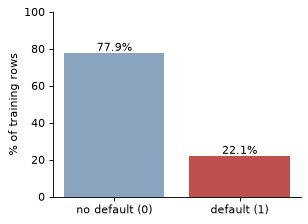

In [3]:
rate_train, rate_test = y_train.mean(), y_test.mean()
print(f"default rate: train {rate_train:.2%}, test {rate_test:.2%}; overall {df[TARGET_COLUMN].mean():.2%}")
fig, ax = plt.subplots(figsize=(4, 3))
counts = y_train.value_counts(normalize=True).sort_index()
ax.bar(["no default (0)", "default (1)"], counts.values * 100, color=["#8aa4bf", "#c0504d"])
for i, v in enumerate(counts.values * 100):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
ax.set_ylabel("% of training rows"); ax.set_ylim(0, 100)
plt.show()
assert abs(rate_train - rate_test) < 0.005  # stratified split keeps base rates aligned

About 22% of clients default, so the target is imbalanced (roughly 78/22). Plain accuracy is therefore a poor yardstick: always predicting "no default" scores about 78% accuracy while catching no defaulters. That is why model selection in this project uses average precision (area under the precision-recall curve) and the deployment rule is expressed as recall at a precision floor.

## 3. Features versus the target

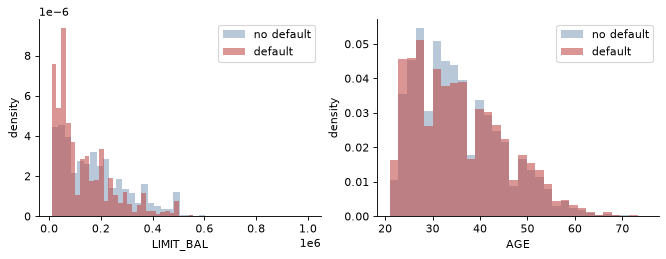

,feature,median_no_default,median_default,mann_whitney_p
0,LIMIT_BAL,150000.0,90000.0,0.000
1,AGE,34.0,34.0,0.605


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, col, bins in [(axes[0], "LIMIT_BAL", 40), (axes[1], "AGE", 30)]:
    for label, colour, name in [(0, "#8aa4bf", "no default"), (1, "#c0504d", "default")]:
        ax.hist(train.loc[train[TARGET_COLUMN] == label, col], bins=bins, density=True,
                alpha=0.6, color=colour, label=name)
    ax.set_xlabel(col); ax.set_ylabel("density"); ax.legend()
plt.show()

summary = []
for col in ["LIMIT_BAL", "AGE"]:
    a = train.loc[train[TARGET_COLUMN] == 0, col]; b = train.loc[train[TARGET_COLUMN] == 1, col]
    summary.append({"feature": col, "median_no_default": a.median(), "median_default": b.median(),
                    "mann_whitney_p": mannwhitneyu(a, b).pvalue})
pd.DataFrame(summary).round(4)

**`LIMIT_BAL`** (the credit limit) is clearly lower for clients who default: the median is markedly smaller in the default group and the difference is highly significant (p-values above). **`AGE`** is different: the two groups have the same median and no significant difference, so it carries little marginal signal on its own. (This does not rule out `AGE` mattering in interaction with other features.)

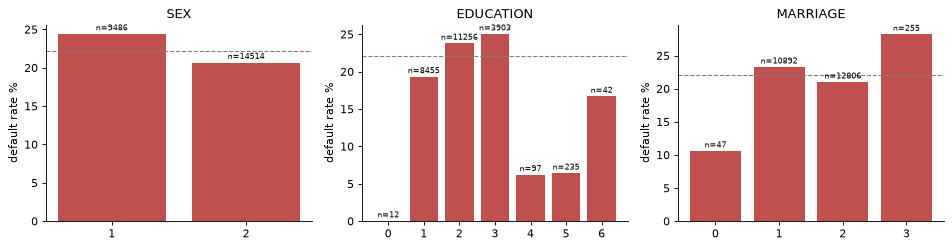

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, col in zip(axes, CATEGORICAL_COLUMNS):
    g = train.groupby(col)[TARGET_COLUMN].agg(["mean", "size"])
    ax.bar(g.index.astype(str), g["mean"] * 100, color="#c0504d")
    for x, (m, n) in enumerate(zip(g["mean"], g["size"])):
        ax.text(x, m * 100 + 0.5, f"n={n}", ha="center", fontsize=7)
    ax.axhline(rate_train * 100, color="grey", ls="--", lw=1)
    ax.set_title(col); ax.set_ylabel("default rate %")
plt.tight_layout(); plt.show()

Among the well-populated categories, default rates differ only modestly (dashed line = overall rate): about 24% vs 21% by `SEX`, and about 19–25% across `EDUCATION` 1–3. The rare codes need care. `EDUCATION` 4 and 5 (n = 97 and 235) default at only about 6%, far below the overall rate and too large a gap to be chance, but together they are only about 1.4% of clients and the notebook offers no explanation for it. `EDUCATION` 0 and 6 and `MARRIAGE` 0 have too few rows (12, 42, 47) to read anything into. Note that `SEX` and `MARRIAGE` are protected-characteristic-type features; see the README's limitations on their use.

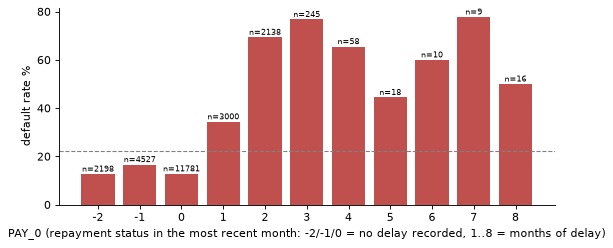

PAY_0,-2,-1,0,1,2,3,4,5,6,7,8
rate,0.127,0.166,0.128,0.344,0.694,0.767,0.655,0.444,0.6,0.778,0.5
n,2198.000,4527.000,11781.000,3000.000,2138.000,245.000,58.000,18.000,10.0,9.000,16.0


In [6]:
pay0 = train.groupby("PAY_0")[TARGET_COLUMN].agg(rate="mean", n="size")
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(pay0.index.astype(str), pay0["rate"] * 100, color="#c0504d")
for x, (r, n) in enumerate(zip(pay0["rate"], pay0["n"])):
    ax.text(x, r * 100 + 1, f"n={n}", ha="center", fontsize=7)
ax.axhline(rate_train * 100, color="grey", ls="--", lw=1)
ax.set_xlabel("PAY_0 (repayment status in the most recent month: -2/-1/0 = no delay recorded, 1..8 = months of delay)")
ax.set_ylabel("default rate %")
plt.show()
pay0.round(3).T

`PAY_0`, the most recent repayment status, is far more informative than the features above: the default rate is roughly 13–17% for clients with no recorded delay (codes -2, -1, 0), about 34% for one month of delay, and roughly 65–77% for two to four months. Codes 5–8 have fewer than 20 rows each, so their rates are too noisy to interpret. Codes -2 and 0 are not described in the dataset documentation, so their exact meaning is an assumption; they are treated as ordinary numeric values here and scaled, not recoded.

## 4. Correlations

                        mean   min   max
BILL_AMT vs BILL_AMT    0.89  0.80  0.95
PAY_x status vs status  0.65  0.48  0.82
PAY_AMT vs PAY_AMT      0.20  0.14  0.31
BILL_AMT vs PAY_AMT     0.19  0.10  0.31


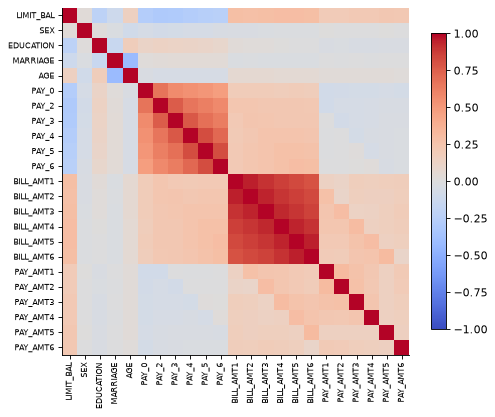


strongest correlations with the target:
PAY_0    0.33
PAY_2    0.27
PAY_3    0.24
PAY_4    0.22
PAY_5    0.20


In [7]:
corr = train.drop(columns=[TARGET_COLUMN]).corr()
bill = [f"BILL_AMT{i}" for i in range(1, 7)]
pay_amt = [f"PAY_AMT{i}" for i in range(1, 7)]
status = ["PAY_0"] + [f"PAY_{i}" for i in range(2, 7)]


def within(cols):
    m = corr.loc[cols, cols].to_numpy()
    return m[~np.eye(len(cols), dtype=bool)]


groups = {
    "BILL_AMT vs BILL_AMT": within(bill),
    "PAY_x status vs status": within(status),
    "PAY_AMT vs PAY_AMT": within(pay_amt),
    "BILL_AMT vs PAY_AMT": corr.loc[bill, pay_amt].to_numpy().ravel(),
}
blocks = pd.DataFrame(
    {k: {"mean": v.mean(), "min": v.min(), "max": v.max()} for k, v in groups.items()}
).T.round(2)
print(blocks)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=7)
fig.colorbar(im, shrink=0.8); plt.show()

target_corr = train.corr()[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)
print("\nstrongest correlations with the target:")
print(target_corr.head(5).round(2).to_string())

assert blocks.loc["BILL_AMT vs BILL_AMT", "min"] > 0.7      # bills are strongly collinear
assert blocks.loc["BILL_AMT vs PAY_AMT", "max"] < 0.5       # bills and payments are not
assert target_corr.index[0] == "PAY_0"                       # PAY_0 is the strongest linear signal

Where the strong correlations are (see the summary table and heatmap): the six `BILL_AMT` columns are highly collinear with each other (every pairwise correlation above 0.7), and the repayment-status columns `PAY_0`…`PAY_6` are moderately-to-strongly correlated with each other. Bill amounts and payment amounts are **not** strongly correlated with each other, and the `PAY_AMT` columns are only weakly correlated among themselves.

Collinear features are kept: dropping them is not needed for a predictive model, tree models are unaffected, and the default (L2-regularised) logistic regression copes with it for prediction — the cost is that individual logistic-regression coefficients would be hard to interpret. `PAY_0` has the strongest linear correlation with the target. Any explanation of *why* the bill columns are collinear (e.g. balances carrying over month to month) is a plausible hypothesis, not something tested here.

## 5. Model comparison

The comparison below is **not computed in this notebook**: it is read from `artifacts/comparison.json`, written by `python -m credit_default.compare`, which runs every candidate through the single `run_model` code path in `src/` on one stratified split. Models are ranked by cross-validated average precision on the training set only; test-set columns are reported but never used to choose.

In [8]:
def load_artifact(name):
    path = ROOT / cfg["output_dir"] / name
    if not path.exists():
        raise FileNotFoundError(f"{path} missing - run `python -m credit_default.{Path(name).stem}` first")
    return json.loads(path.read_text())


comp = load_artifact("comparison.json")
models = {m["name"]: m for m in comp["models"]}
table = pd.DataFrame([{
    "model": m["name"],
    "cv_average_precision": m["cv_mean_average_precision"],
    "P@0.5": m["at_default_threshold"]["precision"], "R@0.5": m["at_default_threshold"]["recall"],
    "P@floor": m["precision"], "R@floor": m["recall"],
} for m in comp["models"]]).round(3)
print("ranked by:", comp["ranked_by"], "| precision floor:", comp["min_precision_constraint"])
table

ranked by: cv_mean_average_precision (training-set cross-validation only) | precision floor: 0.45


,model,cv_average_precision,P@0.5,R@0.5,P@floor,R@floor
0,xgboost_weighted,0.560,0.478,0.614,0.452,0.641
1,xgboost_unweighted,0.532,0.622,0.355,0.445,0.592
2,logistic_regression_balanced,0.505,0.367,0.632,0.439,0.555
3,decision_tree_balanced_depth10,0.463,0.419,0.604,0.455,0.536


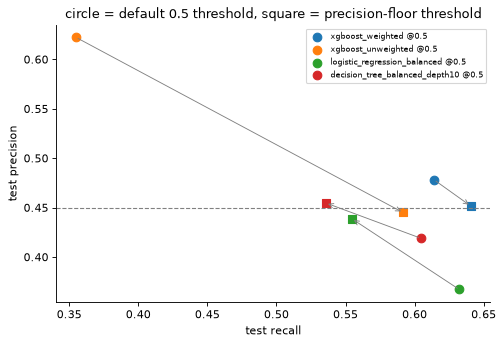

claims below verified by the asserts above


In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for name, m in models.items():
    a, b = m["at_default_threshold"], m
    ax.scatter(a["recall"], a["precision"], marker="o", s=60, label=f"{name} @0.5")
    ax.scatter(b["recall"], b["precision"], marker="s", s=60, color=ax.collections[-1].get_facecolor()[0])
    ax.annotate("", xy=(b["recall"], b["precision"]), xytext=(a["recall"], a["precision"]),
                arrowprops=dict(arrowstyle="->", color="grey", lw=0.8))
ax.axhline(comp["min_precision_constraint"], color="grey", ls="--", lw=1)
ax.set_xlabel("test recall"); ax.set_ylabel("test precision")
ax.set_title("circle = default 0.5 threshold, square = precision-floor threshold")
ax.legend(fontsize=7, loc="upper right"); plt.show()

xgb_w, xgb_u = models["xgboost_weighted"], models["xgboost_unweighted"]
tree, lr = models["decision_tree_balanced_depth10"], models["logistic_regression_balanced"]
assert comp["models"][0]["name"] == "xgboost_weighted"  # best CV average precision
# the precision/recall trade-off between candidates, at the default 0.5 threshold:
assert tree["at_default_threshold"]["recall"] > xgb_u["at_default_threshold"]["recall"] + 0.15
assert xgb_u["at_default_threshold"]["precision"] > tree["at_default_threshold"]["precision"] + 0.1
# at the precision floor, the weighted XGBoost has the best recall of all candidates
assert all(xgb_w["recall"] >= m["recall"] for m in comp["models"])
print("claims below verified by the asserts above")

What this shows (checked by the `assert`s above, not just asserted in prose):

- **Accuracy- or F1-style model choice hides a real trade-off.** At the default 0.5 threshold, the balanced decision tree catches far more defaulters than the unweighted XGBoost (higher recall) but with much lower precision. Picking a "best" model on accuracy or F1 alone would hide that choice.
- **It is mostly a threshold effect.** Moving each model to the precision-floor operating point (squares) brings the candidates much closer together on the same business rule, and the weighted XGBoost then has the highest recall.
- **XGBoost ranks best by cross-validated average precision**, which is why it is the shipped model. The margin over logistic regression is real in cross-validation and on the test split, but differences of a point or two between the other models are within the noise of one split and one seed.

## 6. Sensitivity to the precision floor

The deployment rule is "maximise recall subject to a precision floor". The floor is a business assumption, not a derived optimum (no cost data exists), so here is what moving it does for the main model.

 min_precision  feasible  chosen_threshold  test_precision  test_recall  flagged_share_of_test  false_positives_per_true_positive
          0.35      True             0.367           0.346        0.797                  0.509                              1.890
          0.45      True             0.474           0.452        0.641                  0.314                              1.214
          0.55      True             0.592           0.536        0.529                  0.218                              0.866


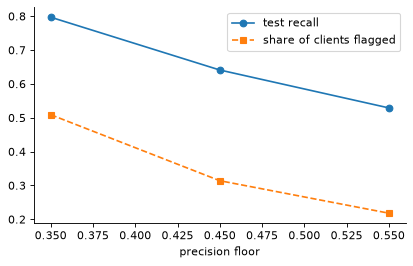

In [10]:
sens = load_artifact("sensitivity.json")
s = pd.DataFrame([r for r in sens["floors"] if r["feasible"]]).round(3)
print(s.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(s["min_precision"], s["test_recall"], "o-", label="test recall")
ax.plot(s["min_precision"], s["flagged_share_of_test"], "s--", label="share of clients flagged")
ax.set_xlabel("precision floor"); ax.legend(); plt.show()

assert s["test_recall"].is_monotonic_decreasing and s["flagged_share_of_test"].is_monotonic_decreasing

A lower floor buys more recall at the price of reviewing many more clients; a higher floor does the reverse (the table above gives the exact numbers). Realised test precision lands close to, and sometimes slightly under, the floor, because the floor is enforced on out-of-fold training predictions rather than on the test set. Choosing the floor needs real review and default costs; see the README.

## 7. What drives the predictions (SHAP)

SHAP splits each client's raw model score into additive per-feature contributions (positive pushes towards "default"). The values here are exact TreeSHAP contributions from XGBoost itself, computed by `credit_default.explain` on a sample of the **training** split; contributions of one-hot columns are summed back to their source feature. The first cell checks the defining property: contributions plus the bias term reproduce the model's score.

In [11]:
import joblib

from credit_default.explain import shap_contributions, summarise

pipe = joblib.load(ROOT / cfg["output_dir"] / "model.joblib")
sample = X_train.sample(n=cfg["explain"]["n_rows"], random_state=cfg["random_state"])
shap_df, bias, max_err = shap_contributions(pipe, sample)
rows = summarise(shap_df, sample)
print(f"{len(sample):,} rows; max |sum(contributions)+bias - model score| = {max_err:.1e}")

top = pd.DataFrame(rows).head(10)[["feature", "mean_abs_shap", "share_of_total", "direction_corr"]].round(3)
print(top.to_string(index=False))

assert max_err < 1e-3
assert rows[0]["feature"] == "PAY_0"  # the strongest signal found in the EDA above
assert abs(sum(r["share_of_total"] for r in rows) - 1) < 1e-6
# the notebook and the CLI artifact must agree
assert load_artifact("explainability.json")["features"][0]["feature"] == rows[0]["feature"]

5,000 rows; max |sum(contributions)+bias - model score| = 2.6e-06
  feature  mean_abs_shap  share_of_total  direction_corr
    PAY_0          0.538           0.276           0.318
LIMIT_BAL          0.212           0.109          -0.946
BILL_AMT1          0.135           0.069          -0.279
 PAY_AMT2          0.117           0.060          -0.914
 PAY_AMT1          0.094           0.048          -0.963
 PAY_AMT3          0.093           0.048          -0.815
    PAY_2          0.083           0.043           0.473
    PAY_3          0.077           0.039           0.857
    PAY_4          0.054           0.028           0.714
    PAY_6          0.053           0.027           0.295


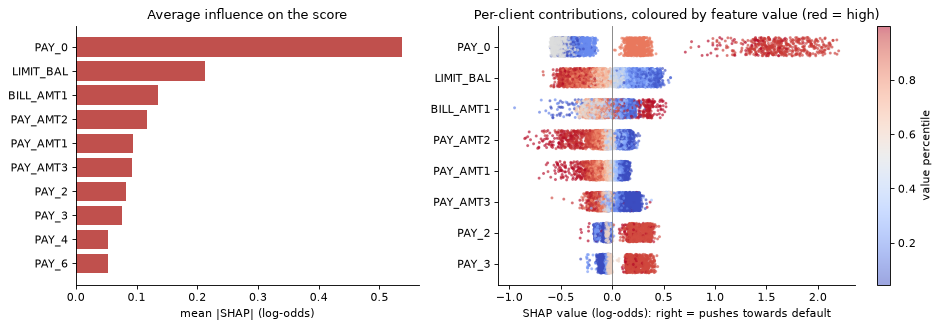

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1, 1.3]})

top10 = rows[:10][::-1]
ax1.barh([r["feature"] for r in top10], [r["mean_abs_shap"] for r in top10], color="#c0504d")
ax1.set_xlabel("mean |SHAP| (log-odds)"); ax1.set_title("Average influence on the score")

numeric_top = [r["feature"] for r in rows if r["feature"] not in CATEGORICAL_COLUMNS][:8][::-1]
for y, feature in enumerate(numeric_top):
    pct = sample[feature].rank(pct=True)  # colour by value percentile
    sc = ax2.scatter(shap_df[feature], np.full(len(sample), y) + np.random.default_rng(0).uniform(-0.3, 0.3, len(sample)),
                     c=pct, cmap="coolwarm", s=3, alpha=0.5)
ax2.set_yticks(range(len(numeric_top))); ax2.set_yticklabels(numeric_top)
ax2.axvline(0, color="grey", lw=0.8)
ax2.set_xlabel("SHAP value (log-odds): right = pushes towards default")
ax2.set_title("Per-client contributions, coloured by feature value (red = high)")
fig.colorbar(sc, ax=ax2, label="value percentile")
plt.tight_layout(); plt.show()

How to read this (figures printed above; numbers in the README are generated from the same artifact):

- **Repayment status dominates.** `PAY_0`, the most recent repayment status, carries by far the largest share of total importance, with the other `PAY_x` statuses further down. This agrees with the EDA, where `PAY_0` had the strongest link to default.
- **`LIMIT_BAL` is the next most important feature, and higher limits push towards lower predicted risk**, as in the EDA (defaulters have lower limits). Larger payment amounts (`PAY_AMT*`) also push predictions towards *lower* risk.
- **Direction summaries need care.** The rank correlation in the table is one number per feature, and it varies widely across the `PAY_x` statuses (about +0.3 to +0.9 for those shown) because status codes are not ordered quantities: the `PAY_0` dot plot shows separate clusters rather than a smooth trend. The dot plot is the better guide.
- **These are descriptions of the model, not causal effects.** SHAP shows what the model relies on. It does not show that changing a client's limit or payment would change their risk, and it was computed on training data, so it says nothing about how well those relationships generalise.